In [1]:

from bokeh.plotting import figure, show
from bokeh.palettes import Turbo256
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper
import plotly.express as px
import numpy as np
import pandas as pd
from bokeh.io import output_notebook
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

output_notebook()

def embedding_plotter(embedding, data=None, hue=None, hover=None):
    '''
    Рисовалка эмбеддинга. 2D renderer: bokeh. 3D renderer: plotly.
    '''
    if embedding.shape[1] not in [2, 3]:
        raise ValueError("Embedding must be 2D or 3D")

    plot_data = pd.DataFrame()
    plot_data['x'] = embedding[:, 0]
    plot_data['y'] = embedding[:, 1]

    if embedding.shape[1] == 3:
        plot_data['z'] = embedding[:, 2]

    if hover is not None:
        if isinstance(hover, str):
            hover = [hover]
        for col in hover:
            if data is not None:
                plot_data[col] = data[col].values

    if embedding.shape[1] == 2:
        p = figure(width=800, height=600, tools=['pan', 'box_zoom', 'reset'])

        if hue is not None and data is not None:
            # Непрерывная цветовая палитра
            color_mapper = LinearColorMapper(palette=Turbo256,
                                          low=data[hue].min(),
                                          high=data[hue].max())

            source = ColumnDataSource({
                'x': plot_data['x'],
                'y': plot_data['y'],
                'hue': data[hue]
            })

            if hover:
                for col in hover:
                    source.data[col] = data[col].values

            p.scatter('x', 'y',
                     source=source,
                     size=8,
                     color={'field': 'hue', 'transform': color_mapper},
                     alpha=0.6)

            color_bar = ColorBar(color_mapper=color_mapper,
                               label_standoff=12,
                               title=hue)
            p.add_layout(color_bar, 'right')

            if hover:
                tooltips = [(col, '@' + col) for col in hover]
                tooltips.append((hue, '@hue'))
                hover_tool = HoverTool(tooltips=tooltips)
                p.add_tools(hover_tool)

        else:
            p.scatter(plot_data['x'], plot_data['y'], size=8, alpha=0.6)

            if hover:
                tooltips = [(col, '@' + col) for col in hover]
                hover_tool = HoverTool(tooltips=tooltips)
                p.add_tools(hover_tool)

        show(p)

    # 3D
    else:
        if hue is not None and data is not None:
            fig = px.scatter_3d(plot_data, x='x', y='y', z='z',
                              color=data[hue],
                              hover_data=hover if hover else None)
        else:
            fig = px.scatter_3d(plot_data, x='x', y='y', z='z',
                              hover_data=hover if hover else None)

        fig.update_layout(
            width=800,
            height=600,
        )


        fig.show()
def representative_point_idx(df):
        points = df.select(pl.col("X", "Y")).to_numpy()
        median = hdm.geomedian(points, axis = 0)
        dists = np.linalg.norm(points - median, axis=1)
        return np.argmin(dists)
import sklearn.cluster as clu

from IPython.display import display, HTML

Loading BokehJS ...

To generate UMAP files from `hexanes_rwp5_constr.cor` run

``` 
 rmsd-map-distances -o hexanes_rwp5_constr hexanes_rwp5_constr.cor
 rmsd-map-umaps -o hexanes_rwp5_constr_umaps hexanes_rwp5_constr.npz
 rmsd-map-umaps -d -o hexanes_rwp5_constr_umaps_d hexanes_rwp5_constr.npz
```

In [4]:
# !rmsd-map-distances -o ./f/cffc_alif ./f/cffc_alif.cor
# !rmsd-map-distances -o ./f/cffc_arom ./f/cffc_arom.cor
# !rmsd-map-distances -o ./f/cffc_arom_alif ./f/cffc_arom_alif.cor
!rmsd-map-distances -o ./f/cffc_all_sample ./f/cffc_all_sample.cor
# alif -> arom -> arom_alif
# !rmsd-map-distances -o ./f/cffc ./f/cffc_all.cor

2026-02-26 21:46:56: Reading and preparing data
Using improp RMSD kernel
Set up a calculation with 5737 fragments, 4 atoms and 2 symmetries
2026-02-26 21:46:56: Starting distance calculations
Using improper RMSD kernel
3.744937s: 1000000/16453716
6.938207s: 2000000/16453716
10.142635s: 3000000/16453716
13.337894s: 4000000/16453716
16.578829s: 5000000/16453716
19.848864s: 6000000/16453716
23.061356s: 7000000/16453716
26.317878s: 8000000/16453716
29.534213s: 9000000/16453716
32.733662s: 10000000/16453716
35.969548s: 11000000/16453716
39.172216s: 12000000/16453716
42.406371s: 13000000/16453716
45.670168s: 14000000/16453716
48.885192s: 15000000/16453716
52.132433s: 16000000/16453716
Saving data
2026-02-26 21:47:54: Saving DataFrame
2026-02-26 21:47:56: Saving matrix
2026-02-26 21:47:57: Finished!


In [ ]:
npz1 = 'f/cffc_alif.npz'
npz2 = 'f/cffc_arom.npz'
npz3 = 'f/cffc_arom_alif.npz'

# Load all three npz files
data1 = np.load(npz1)
data2 = np.load(npz2)
data3 = np.load(npz3)

# Get the arrays
names1 = data1['names']
distances1 = data1['distances']
names2 = data2['names']
distances2 = data2['distances']
names3 = data3['names']
distances3 = data3['distances']

# Concatenate names
all_names = np.concatenate([names1, names2, names3])

# Get sizes
n1 = len(names1)
n2 = len(names2)
n3 = len(names3)
n_total = n1 + n2 + n3

# Create combined distance matrix
# Place each distance matrix as a block on the diagonal
# Use a large value (inf) for cross-distances between different datasets
all_distances = np.full((n_total, n_total), np.inf)

# Fill in the diagonal blocks
all_distances[0:n1, 0:n1] = distances1
all_distances[n1:n1+n2, n1:n1+n2] = distances2
all_distances[n1+n2:n_total, n1+n2:n_total] = distances3

# Set diagonal to zero (distance from fragment to itself)
np.fill_diagonal(all_distances, 0.0)

# Ensure the matrix is symmetric (distance from A to B = distance from B to A)
all_distances = (all_distances + all_distances.T) / 2

# Save concatenated data
np.savez('cffc_all.npz', names=all_names, distances=all_distances)

print(f"Concatenated {n1} + {n2} + {n3} = {n_total} fragments")
print(f"Saved to cffc_all.npz")
print(f"Distance matrix shape: {all_distances.shape}")
print(f"Names array shape: {all_names.shape}")

# Close the files
data1.close()
data2.close()
data3.close()



In [5]:
# !rmsd-map-umaps -o ./cl/cl_constr_umaps ./cl/cl_constr.npz
!rmsd-map-umaps -d -o ./f/cffc_umaps_d ./f/cffc_all_sample.npz

/home/archie/.local/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/archie/.local/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/archie/.local/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/archie/.local/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/archie/.local/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_tran

In [2]:
import rmsd_map
from rmsd_map.mol_io.cor_reader import read_cor_file
from rmsd_map.mol_io.fragment import Fragment
from rmsd_map.rmsd.pipelines import align_fragments
import numpy as np
import polars as pl
import seaborn as sns
cor1 = read_cor_file("./f/cffc_alif.cor")
cor1 = np.asarray(cor1, dtype=object)
cor2 = read_cor_file("./f/cffc_arom.cor")
cor2 = np.asarray(cor2, dtype=object)
cor3 = read_cor_file("./f/cffc_arom_alif.cor")
cor3 = np.asarray(cor3, dtype=object)
cor = read_cor_file("./f/cffc_all.cor")
cor = np.asarray(cor, dtype=object)
#um = pl.read_csv("./f/cffc_umaps_d.csv") # Vanilla UMAP
#ud = pl.read_csv("./f/cffc_umaps_d.csv") # Denity-preserving UMAP 

print(len(cor1)+len(cor2)+len(cor3), len(cor))



# df = ud.filter(pl.col("N") == 6)
# sns.scatterplot(data = df , x="X", y="Y")

38262 38262


In [48]:
# Function to write fragments to .cor file
def write_cor_file(fragments, filename):
    """
    Write a list of Fragment objects to a .cor file.
    
    Parameters:
    -----------
    fragments : list or numpy array
        List of Fragment objects
    filename : str
        Output filename
    """
    with open(filename, 'w') as f:
        for fragment in fragments:
            # Parse fragment ID (format: REFCODE_FRAGNUM)
            frag_id = fragment.id
            if '_' in frag_id:
                refcode, frag_num = frag_id.rsplit('_', 1)
            else:
                refcode = frag_id
                frag_num = '1'
            
            # Write fragment header
            f.write(f"{refcode:8s}  **FRAG**{int(frag_num):8d}\n")
            
            # Write atom coordinates
            for i, (element, coord) in enumerate(zip(fragment.elements, fragment.coords)):
                # Format: element, x, y, z, number (using index as number)
                element_str = element if not element.endswith('%') else element
                f.write(f"{element_str:8s}{coord[0]:12.5f}{coord[1]:12.5f}{coord[2]:12.5f}{i+1:10d}\n")

# Take 33% subsample of each cor file
np.random.seed(42)  # For reproducibility

# Calculate sample sizes (33% of each)
n1 = len(cor1)
n2 = len(cor2)
n3 = len(cor3)

sample_size1 = int(n1 * 0.15)
sample_size2 = int(n2 * 0.15)
sample_size3 = int(n3 * 0.15)

print(f"Original sizes: cor1={n1}, cor2={n2}, cor3={n3}")
print(f"Sample sizes (33%): cor1={sample_size1}, cor2={sample_size2}, cor3={sample_size3}")

# Sample indices
indices1 = np.random.choice(n1, size=sample_size1, replace=False)
indices2 = np.random.choice(n2, size=sample_size2, replace=False)
indices3 = np.random.choice(n3, size=sample_size3, replace=False)

# Create subsamples
cor1_sample = cor1[indices1]
cor2_sample = cor2[indices2]
cor3_sample = cor3[indices3]

# Save each subsample separately
write_cor_file(cor1_sample, "./f/cffc_alif_sample.cor")
write_cor_file(cor2_sample, "./f/cffc_arom_sample.cor")
write_cor_file(cor3_sample, "./f/cffc_arom_alif_sample.cor")

print(f"Saved individual samples:")
print(f"  - ./f/cffc_alif_sample.cor ({len(cor1_sample)} fragments)")
print(f"  - ./f/cffc_arom_sample.cor ({len(cor2_sample)} fragments)")
print(f"  - ./f/cffc_arom_alif_sample.cor ({len(cor3_sample)} fragments)")

# Concatenate all samples
cor_all_sample = np.concatenate([cor1_sample, cor2_sample, cor3_sample])

# Save concatenated sample
write_cor_file(cor_all_sample, "./f/cffc_all_sample.cor")

print(f"Saved concatenated sample:")
print(f"  - ./f/cffc_all_sample.cor ({len(cor_all_sample)} fragments)")
print(f"Total: {len(cor1_sample) + len(cor2_sample) + len(cor3_sample)} fragments")

Original sizes: cor1=16818, cor2=20533, cor3=911
Sample sizes (33%): cor1=2522, cor2=3079, cor3=136
Saved individual samples:
  - ./f/cffc_alif_sample.cor (2522 fragments)
  - ./f/cffc_arom_sample.cor (3079 fragments)
  - ./f/cffc_arom_alif_sample.cor (136 fragments)
Saved concatenated sample:
  - ./f/cffc_all_sample.cor (5737 fragments)
Total: 5737 fragments


In [5]:
help(read_cor_file)

Help on function read_cor_file in module rmsd_map.mol_io.cor_reader:

read_cor_file(filename: str) -> List[rmsd_map.mol_io.fragment.Fragment]



In [4]:
cor1

array([Fragment(id='ABAMEZ_1', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 6.92665, 10.89396,  2.99097],
              [ 7.65098, 10.06413,  3.75122],
              [ 7.20041, 10.80624,  6.43705],
              [ 7.92474,  9.97641,  7.1973 ]], dtype=float32))                                                                 ,
       Fragment(id='AZUCAC_1', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[-3.56539, 11.23258,  7.92563],
              [-2.63918, 11.73541,  8.74041],
              [-4.18321, 13.23532, 10.69327],
              [-4.5001 , 13.32223, 11.99066]], dtype=float32))                                                                 ,
       Fragment(id='AZUCAC_2', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 2.94373,  4.0563 , 11.69594],
              [ 3.93806,  3.40277, 11.1149 ],
              [ 6.64145,  4.05844, 12.05943],
              [ 7.97486,  4.0615 , 11.99066]], dtype=float32))                    

38262 5737


<Axes: xlabel='X', ylabel='Y'>

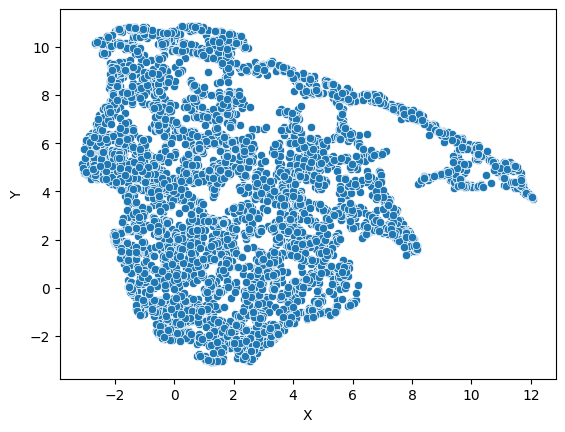

In [3]:
cor = read_cor_file("./f/cffc_all_sample.cor")
cor = np.asarray(cor, dtype=object)
# um = pl.read_csv("./f/cffc_umaps_d.csv") # Vanilla UMAP
ud = pl.read_csv("./f/cffc_umaps_d.csv") # Denity-preserving UMAP 

print(len(cor1)+len(cor2)+len(cor3), len(cor))



df = ud.filter(pl.col("N") == 20)
sns.scatterplot(data = df , x="X", y="Y")

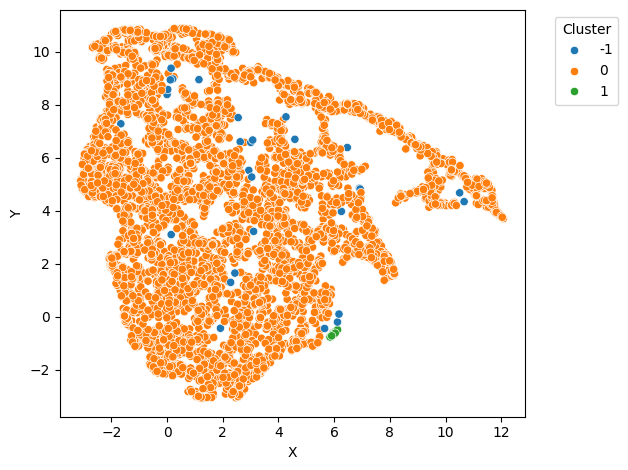

In [4]:

import sklearn.cluster as clu
import matplotlib.pyplot as plt

dbscan = clu.HDBSCAN(min_cluster_size=15,
    min_samples=5,
    cluster_selection_epsilon=0.5,
    metric='euclidean').fit(df.select(pl.col("X", "Y")).to_numpy())
df2 = df.with_columns(pl.Series("label", dbscan.labels_))

sns.scatterplot(data = df2, x = 'X', y = 'Y', hue = 'label', palette='tab10')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
cor[0]

Fragment(id='FANYIG_8', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 0.73484,  4.2122 ,  1.52381],
       [ 1.17896,  5.38701,  1.96437],
       [-0.74707,  6.74199,  3.65017],
       [-0.65266,  8.03472,  3.92922]], dtype=float32))

In [40]:
import numpy as np

def norm_vec(vec):

    vec = np.array(vec, dtype=float)
    norm_val = np.linalg.norm(vec)
    return vec / norm_val


def get_angle(a,b,c):
    a,b,c = np.array(a), np.array(b), np.array(c)
    ab= a-b
    bc = c-b

    # print(ab)
    # print(bc)
    # print(np.linalg.norm(ab))
    # print(np.sum(ab*bc))
    # print(np.sum(ab*bc) / np.linalg.norm(ab) / np.linalg.norm(bc))
    angle = np.arccos(np.clip(np.sum(ab*bc) / np.linalg.norm(ab) / np.linalg.norm(bc), -1.0, 1.0)) / np.pi * 180
    # print(angle)
    return float(angle)
    
result = get_angle(np.array([0,0,0]), np.array([1,1,1]), np.array([2,2,2]))
print(f"Torsion angle: {result:.5f}°")

Torsion angle: 180.00000°


In [41]:

get_angle(cor[3].coords[0],cor[3].coords[1], cor[3].coords[2]),get_angle(cor[3].coords[-1],cor[3].coords[-2], cor[3].coords[-3])


(88.75676727294922, 88.75666046142578)

In [37]:
# for i in df2["label"].unique():
#     # Convert Polars boolean Series to numpy array for indexing
#     mask = (df2["label"] == i).to_numpy()
#     clu0_all = cor[mask]
#     # Sample 100 elements (or all if less than 100)
#     n_samples = min(500, len(clu0_all))
#     # print(clu0_all)
#     if n_samples > 0 and len(clu0_all) > 0:
#         sample_indices = np.random.choice(len(clu0_all), size=n_samples, replace=False)
#         clu0 = clu0_all[sample_indices]
#     else:
#         clu0 = clu0_all
#     clu0_center_idx = 0 # find a central point on umap
#     # Get C-Cl bond atom indices from the reference fragment
#     # This finds all C-Cl bonds (C-Cl-Cl-C pattern) and returns indices in order: [C1, Cl1, C2, Cl2]
#     c_cl_indices = get_c_cl_bond_indices(clu0[clu0_center_idx])
#     # Align all fragments so their C-Cl-Cl-C bonds match the reference fragment's C-Cl bond positions
#     clu0_aligned = partial_align_fragments(clu0, c_cl_indices, n_center=1)
#     # print(clu0_aligned)
#     # clu0_aligned = align_fragments(clu0, 0)
#     print(f'Cluster {i} has {len(clu0_aligned)} fragments (sampled from {len(clu0_all)})')
#     clu0_view = Fragment.plot_fragments(clu0_aligned)
#     display(HTML(clu0_view.write_html(fullpage=True)))

cor[0:1]
clu0_view = Fragment.plot_fragments(cor[3:4])
display(HTML(clu0_view.write_html(fullpage=True)))

In [44]:
classes = []
for cori in cor: 
    ang1, ang2 = get_angle(cori.coords[0],cori.coords[1], cori.coords[2]),get_angle(cori.coords[-1],cori.coords[-2], cori.coords[-3])
    if abs(ang1-ang2) <= 30: classes.append(1)
    elif abs(max(ang1,ang2)-180) <= 30 and abs(min(ang2,ang1)-90) <= 30: classes.append(2)
    else:
        classes.append(999)
        print(ang1,ang2)


137.69491577148438 102.45712280273438
148.30751037597656 99.94727325439453
143.0895538330078 108.98501586914062
92.64930725097656 147.10430908203125
134.88917541503906 170.5529327392578
158.5586395263672 120.76727294921875
96.38203430175781 149.02816772460938
91.36982727050781 137.3706817626953
103.83882141113281 147.380615234375
147.2240753173828 111.56841278076172
121.45480346679688 163.93417358398438
106.29930877685547 147.205078125
159.02516174316406 123.32051086425781
135.428955078125 103.5810775756836
122.18814849853516 157.267578125
156.50282287597656 124.91078186035156
112.91472625732422 144.71566772460938
144.50146484375 113.6291275024414
128.0408935546875 91.10455322265625
110.65719604492188 146.21713256835938
158.867919921875 125.03299713134766
134.2455596923828 97.7160415649414
155.7081298828125 120.48429107666016
115.14334869384766 146.51934814453125
130.9397735595703 93.93550109863281
106.14228820800781 144.00711059570312
145.49078369140625 109.23670959472656
146.45759582

In [49]:
cor1_sample_names = []
for frag in cor1_sample:
    cor1_sample_names.append(frag.id)
cor2_sample_names = []
for frag in cor2_sample:
    cor2_sample_names.append(frag.id)
cor3_sample_names = []
for frag in cor3_sample:
    cor3_sample_names.append(frag.id)
alifs = []
for frag in cor:
    print(frag)
    if frag.id in cor1_sample_names:
        alifs.append('alif')
    elif frag.id in cor2_sample_names:
        alifs.append('arom')
    elif frag.id in cor3_sample_names:
        alifs.append('arom_alif')
    else: alifs.append('hz')

alifs

Fragment(id='FANYIG_8', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 0.73484,  4.2122 ,  1.52381],
       [ 1.17896,  5.38701,  1.96437],
       [-0.74707,  6.74199,  3.65017],
       [-0.65266,  8.03472,  3.92922]], dtype=float32))
Fragment(id='FEHJUA_1', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[19.27049, 10.26459, 11.34972],
       [20.46101,  9.8134 , 11.12257],
       [22.3563 ,  8.31886, 12.65346],
       [22.78805,  7.96944, 13.85002]], dtype=float32))
Fragment(id='DOQJUO_3', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 7.193  ,  7.16357, 10.10798],
       [ 6.39408,  7.86457,  9.33035],
       [ 4.00516,  8.22429,  7.69515],
       [ 2.70895,  8.24926,  7.99554]], dtype=float32))
Fragment(id='WARTES_1', elements=array(['C', 'F', 'F', 'C'], dtype='<U2'), coords=array([[ 4.210000e-03,  1.872470e+00,  9.496590e+00],
       [-7.596100e-01,  9.895100e-01,  1.023041e+01],
       [-1.333690e+00, -4.714000e-01,  7.7555

['alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 'alif',
 

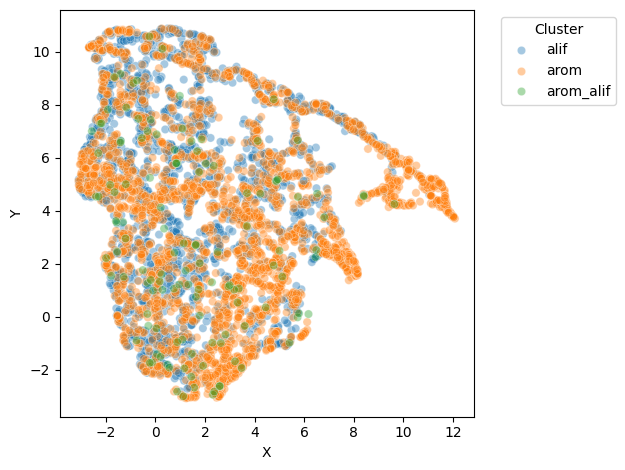

In [50]:
df3 = df2.with_columns(pl.Series("type", alifs))

sns.scatterplot(data = df3, x = 'X', y = 'Y', hue = 'type', palette='tab10', alpha = 0.4)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

137.69491577148438 102.45712280273438
148.30751037597656 99.94727325439453
143.0895538330078 108.98501586914062
92.64930725097656 147.10430908203125
134.88917541503906 170.5529327392578
158.5586395263672 120.76727294921875
96.38203430175781 149.02816772460938
91.36982727050781 137.3706817626953
103.83882141113281 147.380615234375
147.2240753173828 111.56841278076172
121.45480346679688 163.93417358398438
106.29930877685547 147.205078125
159.02516174316406 123.32051086425781
135.428955078125 103.5810775756836
122.18814849853516 157.267578125
156.50282287597656 124.91078186035156
112.91472625732422 144.71566772460938
144.50146484375 113.6291275024414
128.0408935546875 91.10455322265625
110.65719604492188 146.21713256835938
158.867919921875 125.03299713134766
134.2455596923828 97.7160415649414
155.7081298828125 120.48429107666016
115.14334869384766 146.51934814453125
130.9397735595703 93.93550109863281
106.14228820800781 144.00711059570312
145.49078369140625 109.23670959472656
146.45759582

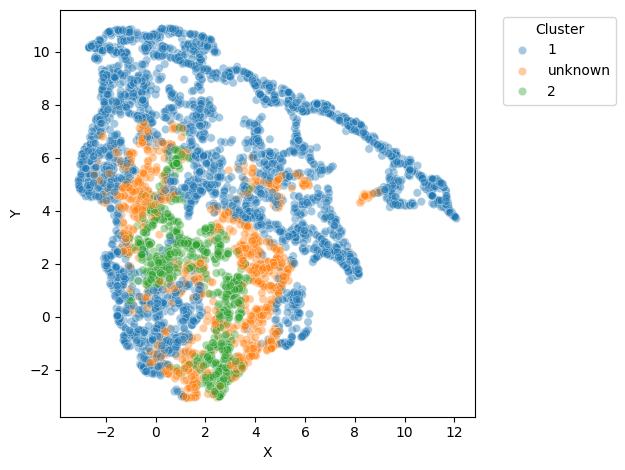

In [54]:
classes = []
threshold = 30
for cori in cor: 
    ang1, ang2 = get_angle(cori.coords[0],cori.coords[1], cori.coords[2]),get_angle(cori.coords[-1],cori.coords[-2], cori.coords[-3])
    if abs(ang1-ang2) <= threshold: classes.append('1')
    elif abs(max(ang1,ang2)-180) <= threshold and abs(min(ang2,ang1)-90) <= threshold: classes.append('2')
    else:
        classes.append('unknown')
        print(ang1,ang2)
df4 = df3.with_columns(pl.Series("classes", classes))

sns.scatterplot(data = df4, x = 'X', y = 'Y', hue = 'classes', palette='tab10', alpha = 0.4)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
df3

X,Y,N,label,type
f64,f64,i64,i64,str
4.2378182,3.537078,6,1,"""alif"""
13.308617,9.045673,6,1,"""alif"""
12.965558,4.6922817,6,1,"""alif"""
-3.057944,4.253425,6,2,"""alif"""
8.049342,5.8966417,6,1,"""alif"""
…,…,…,…,…
10.080952,15.490492,6,1,"""alif"""
12.790175,2.5735495,6,1,"""arom_alif"""
12.628705,4.9966903,6,1,"""arom_alif"""


In [ ]:
import scipy
values = []
for x in cor:
    # print(x.coords[1])
    values.append(float(scipy.spatial.distance.euclidean(np.array(x.coords[1]), np.array(x.coords[2]))))
values[0], cor[0]

In [ ]:
df3 = df2.with_columns(pl.Series('length', values))

# Use continuous colormap for bond lengths (viridis is a good default for continuous data)
scatter = sns.scatterplot(data = df3, x = 'X', y = 'Y', hue = 'length', 
                         palette='viridis', s=50, alpha=0.6)
# Get the colorbar from the scatter plot
norm = plt.Normalize(df3['length'].min(), df3['length'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Cl-Cl bond length', rotation=270, labelpad=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('UMAP visualization colored by Cl-Cl bond length')
plt.tight_layout()
plt.show()


# Use continuous colormap for bond lengths (viridis is a good default for continuous data)
df4 = df3.filter(df3['length'] >= 3.07)
scatter = sns.scatterplot(data = df4, x = 'X', y = 'Y', hue = 'length', 
                         palette='viridis', s=50, alpha=0.6)
# Get the colorbar from the scatter plot
norm = plt.Normalize(df4['length'].min(), df4['length'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Cl-Cl bond length', rotation=270, labelpad=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('UMAP visualization colored by Cl-Cl bond length')
plt.tight_layout()
plt.show()
# Set publication-quality style
plt.rcParams.update({
    'font.size': 4,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5
})

# Create scatterplot colored by label
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df4, x='X', y='Y', hue='length', 
                palette='viridis', alpha=0.6, s=25, edgecolors='white', linewidth=0.3, ax=ax, legend=False)
norm = plt.Normalize(df4['length'].min(), df4['length'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Cl-Cl bond length', rotation=270, labelpad=20)
ax.set_xlabel('Dimension 1', fontsize=8, fontweight='normal')
ax.set_ylabel('Dimension 2', fontsize=8, fontweight='normal')
# ax.set_title('UMAP visualization colored by hexane conformer type', fontsize=12, fontweight='bold', pad=15)
# ax.legend(title='Cluster', 
#           frameon=True, fancybox=True, shadow=True, fontsize=8, title_fontsize=8)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.tight_layout()
plt.savefig('./final_images/umap_cl_bonds.png', dpi=400)
plt.show()



sns.scatterplot(data = df4, x = 'X', y = 'Y', hue = 'label', palette='tab10')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Create scatterplot colored by label
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df4, x='X', y='Y', hue='label', 
                palette='tab10', alpha=0.6, s=25, edgecolors='white', linewidth=0.3, ax=ax)
ax.set_xlabel('Dimension 1', fontsize=8, fontweight='normal')
ax.set_ylabel('Dimension 2', fontsize=8, fontweight='normal')
# ax.set_title('UMAP visualization colored by hexane conformer type', fontsize=12, fontweight='bold', pad=15)
ax.legend(title='Cluster', 
          frameon=True, fancybox=True, shadow=True, fontsize=8, title_fontsize=8,
          loc='center right', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.tight_layout()
plt.savefig('./final_images/umap_cl_cluster.png', dpi=400)
plt.show()


In [ ]:
# Plot distribution of Cl-Cl bond lengths
plt.figure(figsize=(10, 6))
sns.histplot(data=df3, x='length', bins=50, kde=True, color='steelblue', alpha=0.7)
plt.xlabel('Cl-Cl bond length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Cl-Cl bond lengths', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some statistics
print(f"Mean: {df3['length'].mean():.4f}")
print(f"Median: {df3['length'].median():.4f}")
print(f"Std: {df3['length'].std():.4f}")
print(f"Min: {df3['length'].min():.4f}")
print(f"Max: {df3['length'].max():.4f}")


In [56]:
for i in df4["classes"].unique():
    # Convert Polars boolean Series to numpy array for indexing
    # Need parentheses to ensure correct operator precedence: & has higher precedence than ==
    mask = ((df4["classes"] == i)).to_numpy()
    clu0_all = cor[mask]
    
    # Skip if no fragments match the filter
    if len(clu0_all) == 0:
        print(f'Cluster {i} has 0 fragments (no fragments with length >= 3.07)')
        continue
    
    # Sample 100 elements (or all if less than 100)
    n_samples = min(100, len(clu0_all))
    # print(clu0_all)
    if n_samples > 0 and len(clu0_all) > 0:
        sample_indices = np.random.choice(len(clu0_all), size=n_samples, replace=False)
        clu0 = clu0_all[sample_indices]
    else:
        clu0 = clu0_all
    clu0_center_idx = 0 # find a central point on umap
    clu0_aligned = align_fragments(clu0, clu0_center_idx) # and align all fragments to it
    # print(clu0_aligned)
    print(f'Cluster {i} has {len(clu0_aligned)} fragments (sampled from {len(clu0_all)})')
    clu0_view = Fragment.plot_fragments(clu0_aligned)
    display(HTML(clu0_view.write_html(fullpage=True)))

Cluster unknown has 100 fragments (sampled from 1114)


Cluster 2 has 100 fragments (sampled from 869)


Cluster 1 has 100 fragments (sampled from 3754)


In [ ]:
for i in df3["label"].unique():
    # Convert Polars boolean Series to numpy array for indexing
    # Need parentheses to ensure correct operator precedence: & has higher precedence than ==
    mask = ((df3["label"] == i) & (df3['length'] >= 3.07)).to_numpy()
    clu0_all = cor[mask]
    
    # Skip if no fragments match the filter
    if len(clu0_all) == 0:
        print(f'Cluster {i} has 0 fragments (no fragments with length >= 3.07)')
        continue
    
    # Sample 100 elements (or all if less than 100)
    n_samples = min(100, len(clu0_all))
    # print(clu0_all)
    if n_samples > 0 and len(clu0_all) > 0:
        sample_indices = np.random.choice(len(clu0_all), size=n_samples, replace=False)
        clu0 = clu0_all[sample_indices]
    else:
        clu0 = clu0_all
    clu0_center_idx = 0 # find a central point on umap
    clu0_aligned = align_fragments(clu0, clu0_center_idx) # and align all fragments to it
    # print(clu0_aligned)
    print(f'Cluster {i} has {len(clu0_aligned)} fragments (sampled from {len(clu0_all)})')
    clu0_view = Fragment.plot_fragments(clu0_aligned)
    display(HTML(clu0_view.write_html(fullpage=True)))



In [ ]:
for i in df2["label"].unique():
    # Convert Polars boolean Series to numpy array for indexing
    mask = (df2["label"] == i && df2['length'] >= 3.07).to_numpy()
    clu0_all = cor[mask]
    # Sample 100 elements (or all if less than 100)
    n_samples = min(100, len(clu0_all))
    # print(clu0_all)
    if n_samples > 0 and len(clu0_all) > 0:
        sample_indices = np.random.choice(len(clu0_all), size=n_samples, replace=False)
        clu0 = clu0_all[sample_indices]
    else:
        clu0 = clu0_all
    clu0_center_idx = 0 # find a central point on umap
    clu0_aligned = align_fragments(clu0, clu0_center_idx) # and align all fragments to it
    # print(clu0_aligned)
    print(f'Cluster {i} has {len(clu0_aligned)} fragments (sampled from {len(clu0_all)})')
    clu0_view = Fragment.plot_fragments(clu0_aligned)
    display(HTML(clu0_view.write_html(fullpage=True)))
